# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [27]:
### LOADING THE DATASET
# Dataset contain 60K colored images of dimension 32x32x3

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


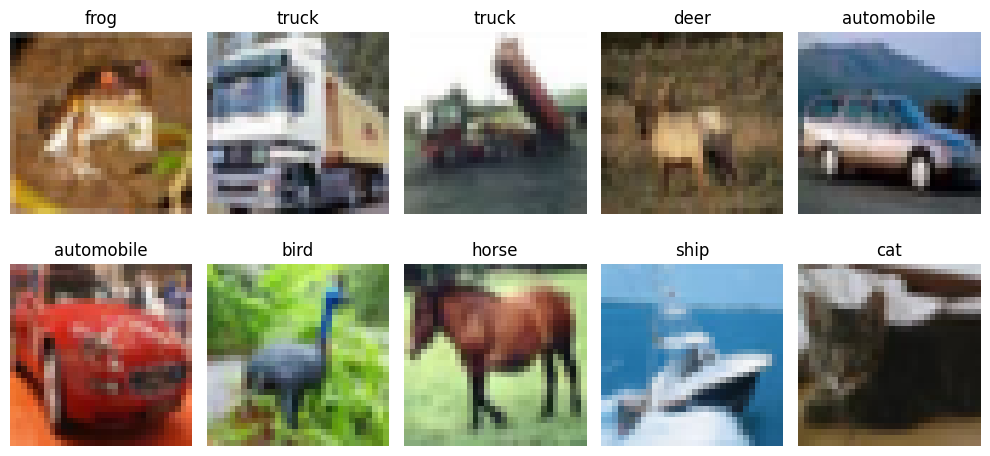

In [28]:
### HOW A SAMPLE IMAGE LOOKS LIKE

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [29]:
### PREPROCESSING --> NORMALIZATION


x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [30]:
### ANN MODEL
### It treats images as flat vectors


ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2717 - loss: 1.9923 - val_accuracy: 0.3158 - val_loss: 1.8442
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3201 - loss: 1.8654 - val_accuracy: 0.3642 - val_loss: 1.7685
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3351 - loss: 1.8176 - val_accuracy: 0.3720 - val_loss: 1.7790
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3548 - loss: 1.7721 - val_accuracy: 0.4000 - val_loss: 1.7069
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3607 - loss: 1.7536 - val_accuracy: 0.3980 - val_loss: 1.6951
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3696 - loss: 1.7268 - val_accuracy: 0.4188 - val_loss: 1.6563
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3804 - loss: 1.7049 - val_accuracy: 0.4182 - val_loss: 1.6418
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3816 - loss: 1.6998 - val_accuracy: 0.

In [31]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4454 - loss: 1.5792
ANN Test Accuracy: 0.4453999996185303


In [32]:
### CNN MODEL
### Usually better than ANN



cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4719 - loss: 1.4862 - val_accuracy: 0.4484 - val_loss: 1.6321
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6114 - loss: 1.1103 - val_accuracy: 0.6314 - val_loss: 1.0563
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6706 - loss: 0.9472 - val_accuracy: 0.6408 - val_loss: 1.0456
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7139 - loss: 0.8178 - val_accuracy: 0.6440 - val_loss: 1.0195
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7457 - loss: 0.7327 - val_accuracy: 0.6738 - val_loss: 1.0602
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7742 - loss: 0.6477 - val_accuracy: 0.7124 - val_loss: 0.8361
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7973 - loss: 0.5776 - val_accuracy: 0.7194 - val_loss: 0.8926
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8140 - loss: 0.5215 - val_accuracy: 

In [33]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7071 - loss: 1.4474
CNN Test Accuracy: 0.707099974155426


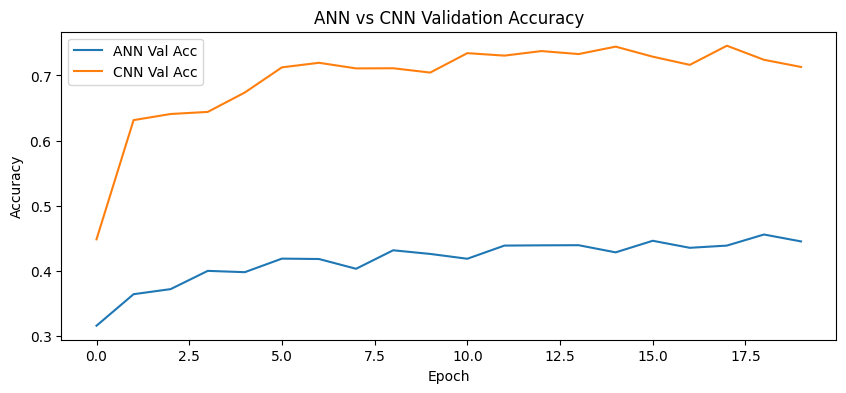

In [34]:
### COMPARING LEARNING CURVES

plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [35]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3699 - loss: 1.7306 - val_accuracy: 0.5104 - val_loss: 1.3668
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4662 - loss: 1.4904 - val_accuracy: 0.5450 - val_loss: 1.2689
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5015 - loss: 1.3933 - val_accuracy: 0.5774 - val_loss: 1.1673
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5259 - loss: 1.3353 - val_accuracy: 0.5998 - val_loss: 1.1135
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5391 - loss: 1.2965 - val_accuracy: 0.6142 - val_loss: 1.0780
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5545 - loss: 1.2621 - val_accuracy: 0.5930 - val_loss: 1.1902
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5635 - loss: 1.2359 - val_accuracy: 0.6248 - val_loss: 1.0539
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5694 - loss: 1.

In [36]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4454
1,CNN,0.7071
2,Augmented CNN,0.6073


In [37]:
### IMPROVING THE ANN MODEL


ann_model = models.Sequential([

    # Input layer
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    # Hidden layer 1
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Hidden layer 2
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Hidden layer 3
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2199 - loss: 2.0750 - val_accuracy: 0.2958 - val_loss: 1.9105
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2829 - loss: 1.9345 - val_accuracy: 0.3282 - val_loss: 1.8760
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2994 - loss: 1.8930 - val_accuracy: 0.3532 - val_loss: 1.8352
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3119 - loss: 1.8624 - val_accuracy: 0.3602 - val_loss: 1.8127
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3232 - loss: 1.8386 - val_accuracy: 0.3564 - val_loss: 1.7851
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3260 - loss: 1.8269 - val_accuracy: 0.3612 - val_loss: 1.7818
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3381 - loss: 1.8113 - val_accuracy: 0.3824 - val_loss: 1.7451
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3387 - loss: 1.8025 - val_accuracy: 0.

In [38]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3655 - loss: 1.7891
ANN Test Accuracy: 0.36550000309944153


In [39]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.3655
1,CNN,0.7071
2,Augmented CNN,0.6073


In [40]:
### UPDATED CNN MODEL
### CHANGING CNN Filters --> 32--> 64 --> 128



cnn_model = models.Sequential([

    # First convolution block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Second convolution block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third convolution block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation='relu'),

    # Dropout
    layers.Dropout(0.4),

    # Output layer
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3900 - loss: 1.6565 - val_accuracy: 0.5312 - val_loss: 1.2865
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5424 - loss: 1.2818 - val_accuracy: 0.6092 - val_loss: 1.1005
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6056 - loss: 1.1244 - val_accuracy: 0.6476 - val_loss: 1.0240
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6461 - loss: 1.0171 - val_accuracy: 0.6656 - val_loss: 0.9622
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6745 - loss: 0.9343 - val_accuracy: 0.6740 - val_loss: 0.9334
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6994 - loss: 0.8656 - val_accuracy: 0.6824 - val_loss: 0.9147
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7192 - loss: 0.8116 - val_accuracy: 0.7014 - val_loss: 0.8623
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7375 - loss: 0.7623 - val_accuracy: 

In [41]:
deep_cnn_test_loss, deep_cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)

print("Deep CNN Test Accuracy:", deep_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7164 - loss: 0.8462
Deep CNN Test Accuracy: 0.7164000272750854


In [42]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train CNN with EarlyStopping
early_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7735 - loss: 0.6449 - val_accuracy: 0.7186 - val_loss: 0.8306
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7838 - loss: 0.6078 - val_accuracy: 0.7206 - val_loss: 0.8247
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7963 - loss: 0.5812 - val_accuracy: 0.7352 - val_loss: 0.7913
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8052 - loss: 0.5495 - val_accuracy: 0.7376 - val_loss: 0.8189
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8108 - loss: 0.5286 - val_accuracy: 0.7256 - val_loss: 0.8382
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8225 - loss: 0.4979 - val_accuracy: 0.7174 - val_loss: 0.9118


In [43]:
early_test_loss, early_test_acc = cnn_model.evaluate(x_test_norm, y_test)

print("CNN with EarlyStopping Accuracy:", early_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7331 - loss: 0.8041
CNN with EarlyStopping Accuracy: 0.7330999970436096


In [44]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN",
        "CNN (32→64→128)",
        "CNN + EarlyStopping"
    ],

    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1],
        deep_cnn_test_acc,
        early_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.3655
1,CNN,0.7071
2,Augmented CNN,0.6073
3,CNN (32→64→128),0.7164
4,CNN + EarlyStopping,0.7331
